# Laboratório - Busca Adversarial e Minimax

## Ajustando ambiente

In [1]:
import random
import math
import matplotlib.pyplot as plt
import copy

## Motivação

Buscas adversariais contemplam métodos que permitem o estudo de
ambientes onde **agentes possuem objetivos conflitantes**. Para
pesquisadores de IA, a natureza simplificada dos jogos (como xadrez, Go
e pôquer) é uma grande vantagem, pois o estado do jogo é fácil de
representar e os agentes são restritos a um número pequeno de ações com
efeitos definidos por regras precisas. Ao contrário do caos das
escaramuças do mundo real, os jogos oferecem um laboratório controlado
para modelar agentes que tentam ativamente derrotar uns aos outros.

Em cenários modernos, as técnicas de busca adversarial e a teoria dos
jogos expandiram-se para além dos tabuleiros, sendo fundamentais na
análise de **sistemas econômicos complexos**, como leilões de direitos
de exploração e definição de preços competitivos. No campo da
**segurança cibernética**, esses métodos são aplicados para detectar
comportamentos anômalos e modelar a proliferação de malwares, combatendo
inclusive ataques de *phishing* e extorsão automatizados. A **interação
entre humanos e robôs** em ambientes dinâmicos, como a negociação de
manobras de ultrapassagem entre um carro autônomo e motoristas humanos,
também é formulada através desses princípios estratégicos. Além disso, a
aplicação em jogos de vídeo de larga escala, como **StarCraft II**,
exige que os agentes lidem com observabilidade parcial e decisões em
tempo real, aproximando-se da complexidade do mundo real. Por fim, a
busca adversarial fornece a base matemática para os **Jogos de
Assistência**, cruciais para o problema do **alinhamento de valores**,
onde um agente deve agir em benefício de um humano mesmo sob incerteza
sobre os objetivos reais desse usuário.

### Métodos de Busca Adversarial

- **Minimax:** Um algoritmo para encontrar a jogada ideal em jogos
  determinísticos de informação perfeita.
- **Poda Alpha-Beta (Alpha–Beta Pruning):** Uma técnica que aumenta a
  eficiência da busca, ignorando partes da árvore que não influenciam a
  decisão final.
- **Busca Heurística:** Utilizada quando não há tempo para explorar a
  árvore até o fim, aplicando uma **função de avaliação** para estimar
  quem está vencendo.
- **Monte Carlo Tree Search (MCTS):** Uma estratégia que estima o valor
  de um estado através de médias de simulações (playouts) completas do
  jogo.
- **Expectiminimax:** Uma generalização do Minimax para **jogos
  estocásticos** que incluem elementos de sorte, como dados.
- **Abordagens para Informação Imperfeita:** Métodos que utilizam
  **estados de crença** para lidar com jogos onde nem todos os dados são
  visíveis para todos os jogadores (como pôquer ou Kriegspiel).

## Objetivos de aprendizagem

- **Modelar um jogo competitivo como um problema de busca**,
  identificando estados, ações, resultados, testes terminais e funções
  de utilidade.
- **Explicar o funcionamento do algoritmo Minimax**, compreendendo como
  jogadores MAX e MIN alternam decisões para escolher movimentos ótimos.
- **Simular partidas completas com Minimax**, observando como a IA
  avalia estados futuros e por que o Jogo da Velha, com jogadores
  ótimos, tende ao empate.
- **Comparar Minimax exaustivo e Poda Alpha-Beta**, reconhecendo que a
  poda reduz o número de estados avaliados sem alterar a decisão ótima.
- **Interpretar os valores de α e β durante a busca**, entendendo como
  eles representam limites de decisão para MAX e MIN e quando permitem
  descartar ramos da árvore.
- **Analisar o impacto da ordem das ações na eficiência da Poda
  Alpha-Beta**, comparando execuções com ordem normal, reversa e
  embaralhada.
- **Aplicar H-Minimax com limite de profundidade**, entendendo por que
  jogos maiores exigem cortes na busca e avaliações aproximadas de
  estados não terminais.
- **Construir e interpretar uma função heurística simples**, baseada nos
  alinhamentos vencedores possíveis do tabuleiro.
- **Reconhecer limitações da busca heurística**, especialmente o efeito
  horizonte, quando uma ameaça importante fica além da profundidade
  analisada.
- **Usar métricas de busca para avaliar desempenho**, como número de nós
  visitados, testes terminais, profundidade máxima e quantidade de podas
  realizadas.

## Fundamentação Teórica

Na unidade anterior, trabalhamos com agentes **baseados em objetivos**.
Esse tipo de agente, simplesmente busca alcançar um estado que satisfaça
uma condição de vitória ou meta, o que é análogo a problemas de
planejamento onde o resultado desejado deve ser garantido
independentemente das ações externas. A partir desse momento, iremos
trabalhar com **agentes baseados em utilidade**. Agentes baseados em
utilidade operam em ambientes competitivos onde existem múltiplos
resultados possíveis com diferentes graus de “desejabilidade”. Nesses
casos, a IA não busca apenas “chegar ao fim”, mas sim maximizar um valor
numérico que representa seu desempenho. Dessa forma, o agente consegue
distinguir entre uma vitória esmagadora, um empate ou uma derrota
marginal, permitindo uma tomada de decisão mais refinada em jogos
complexos.

### Minimax

Como ja mencionado, um dos motores de busca tradicionais de busca
competitiva esta associado ao algoritmo chamado Minimax. No Minimax, a
**função de utilidade** (payoff) é o componente que define o valor
numérico final para um jogador quando o jogo atinge um **estado
terminal**. Ela mapeia o resultado do jogo (vitória, derrota ou empate)
em um número real, permitindo que o algoritmo compare diferentes
caminhos na árvore de jogo.

A **árvore de jogo** uma representação estruturada de todas as
possibilidades de jogadas em uma partida, sobreposta ao grafo do espaço
de estados. Cada **nó** da árvore representa um “estado” ou posição
específica do jogo (como a configuração atual de peças em um tabuleiro).
As **arestas** (ou ramos) que conectam esses nós representam os
movimentos legais que um jogador pode realizar para transformar um
estado em outro. A árvore é organizada em níveis que representam os
turnos. Para jogos complexos como o xadrez, essa árvore é vasta (com
mais de $10^{40}$ nós), sendo considerada mais um construto teórico do
que algo que possa ser totalmente realizado fisicamente

Em algoritmos de **busca adversarial**, como o **Minimax**, os jogos são
definidos por **componentes formais** que caracterizam seu espaço de
estados e mecânicas. Tradicionalmente, esses componentes são os
seguintes:

- **Estado Inicial ($S_0$):** Especifica como o jogo está configurado em
  seu início.
- **TO-MOVE($s$):** Identifica o jogador cuja vez é de realizar um
  movimento no estado $s$.
- **ACTIONS($s$):** Define o conjunto de **movimentos legais** ou ações
  que podem ser executadas em um determinado estado.
- **RESULT($s, a$):** Representa o **modelo de transição**, que
  determina o novo estado resultante da aplicação da ação $a$ no estado
  $s$.
- **IS-TERMINAL($s$):** O **teste terminal**, que retorna verdadeiro
  quando o jogo acabou e falso caso contrário.
- **UTILITY($s, p$):** A **função de utilidade** (também conhecida como
  função de *payoff*), que define o **valor numérico final** para o
  jogador $p$ quando o jogo termina em um estado terminal.

A integração desses elementos permite a construção da árvore de jogo
(ver abaixo). O algoritmo Minimax utiliza essa árvore para determinar a
**decisão ótima**, assumindo que todos os agentes jogam de forma ideal
para maximizar seus próprios resultados.

O que seria uma decisão ótima para o Minimax?

Uma **decisão ótima** no algoritmo Minimax é a escolha de um movimento
que garante a **máxima utilidade** para o jogador (MAX), partindo da
premissa de que o oponente (MIN) também jogará de forma ideal para
minimizar esse valor. Essa decisão é determinada pelo cálculo do **valor
Minimax** de cada estado sucessor a partir do nó raiz, representando a
utilidade de estar naquele estado assumindo que ambos os lados ajam
perfeitamente até o fim do jogo. Formalmente, a decisão ótima é a ação
que leva ao estado com o **maior valor Minimax possível**. O algoritmo
assume um cenário de “pior caso” onde o adversário é implacável; se o
oponente não jogar de forma ideal, o jogador MAX poderá obter um
resultado ainda melhor do que o valor previsto pela decisão ótima, mas
nunca pior.

### Árvore de jogo

Abaixo, observe uma partida a apenas **três movimentos do fim**. Através
desta simulação prática, podemos visualizar conceitos fundamentais como
a construção da árvore de jogo: a) a definição de **ply** (turnos de
decisão de cada jogador); b) a aplicação da **função de utilidade** e;
c) o processo de **retropropagação de valores**, que permite ao
algoritmo identificar a jogada que garante o melhor resultado possível,
assumindo que ambos os lados joguem de forma ideal.

A árvore de jogos é a estrutura fundamental na busca adversarial. Ela
serve como o modelo teórico sobre o qual operam algoritmos essenciais: o
**Minimax**, que explora essa árvore para determinar a decisão ótima
através de uma busca em profundidade; a **Poda Alpha-Beta**, que otimiza
esse processo ao descartar ramos da árvore que comprovadamente não
afetam a escolha final; e o **Monte Carlo Tree Search (MCTS)**, que
constrói e expande a árvore de forma seletiva por meio de simulações e
cálculos de média de utilidade.

## Implementação

A partir desse momento, traduzimos a estrutura lógica do jogo para
ferramentas de manipulação de dados. Aqui construímos as funções
utilitárias que permitem ao algoritmo “enxergar” o tabuleiro e
“experimentar” movimentos. O roteiro seguirá estas etapas fundamentais:
a) Modelo de Transição: Implementação das funções ACTIONS e RESULT para
listar jogadas legais e gerar novos estados no tabuleiro; b) Avaliação
de Resultados: Construção do teste terminal (IS-TERMINAL) e da função de
utilidade (UTILITY) para identificar e pontuar o fim da partida; c)
Busca e Decisão: Execução do algoritmo Minimax para explorar a árvore de
jogo e retropropagar os valores das folhas até a raiz, definindo a
estratégia ótima.

### Instanciando ambiente do agente

In [2]:
def create_board():
    """Cria e retorna um tabuleiro de Tic-tac-toe 3x3 vazio."""
    return [[None for col_idx in range(3)] for row_idx in range(3)]

In [3]:
board_example = create_board()
for row in board_example:
    print(row)

[None, None, None]
[None, None, None]
[None, None, None]

### Função para visualizar o tabuleiro do Jogo da Velha

In [4]:
def draw_board(board, title="Tabuleiro"):
    """
    Gera uma imagem do tabuleiro usando matplotlib.
    """
    figure, axis = plt.subplots(figsize=(4, 4))

    axis.set_xlim(0, 3)
    axis.set_ylim(0, 3)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_title(title)

    # Desenha as linhas do tabuleiro
    for position in range(1, 3):
        axis.plot([position, position], [0, 3], linewidth=2, color="black")
        axis.plot([0, 3], [position, position], linewidth=2, color="black")

    # Desenha X e O nas casas ocupadas
    for row_idx in range(len(board)):
        for col_idx in range(len(board[row_idx])):
            cell = board[row_idx][col_idx]

            if cell is not None:
                x_position = col_idx + 0.5
                y_position = 2.5 - row_idx

                axis.text(
                    x_position,
                    y_position,
                    cell,
                    fontsize=40,
                    ha="center",
                    va="center"
                )

    plt.show()

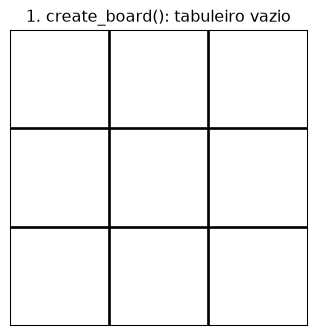

In [5]:
draw_board(board_example, title="1. create_board(): tabuleiro vazio")

### Função para ações validadas e movimentações

Abaixo, implementamos a mecânica de exploração do tabuleiro através de
dois componentes fundamentais: o mapeamento de ACTIONS(s) e o modelo de
transição RESULT(s, a).

In [6]:
def get_available_actions(board):
    """
    Retorna todas as posições vazias do tabuleiro.
    Cada ação é representada como uma tupla: (linha, coluna)

    Esta função corresponde à ideia de ACTIONS(s).
    """
    available_actions = []

    for row_idx in range(len(board)):
        for col_idx in range(len(board[row_idx])):
            if board[row_idx][col_idx] is None:
                action = (row_idx, col_idx)
                available_actions.append(action)

    return available_actions

In [7]:
def apply_move(board, action, player):
    """
    Aplica uma jogada no tabuleiro.
    Esta função corresponde à ideia de RESULT(s, a)
    """
    board[action[0]][action[1]] = player

In [8]:
def undo_move(board, action, player = None):
    """
    Desfaz uma jogada previamente aplicada.
    Isso permite testar vários ramos da árvore de jogo usando o mesmo tabuleiro.
    """
    board[action[0]][action[1]] = player

#### Demonstração

In [9]:
player, action = "X", (1, 1)
apply_move(board_example, action, player)

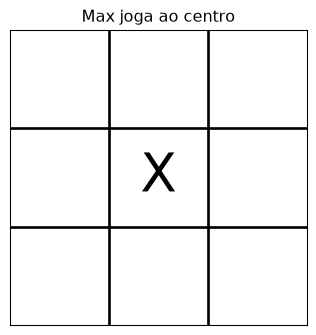

In [10]:
draw_board(board_example, title="Max joga ao centro")

In [11]:
player, action = None, (1, 1)
undo_move(board_example, action)

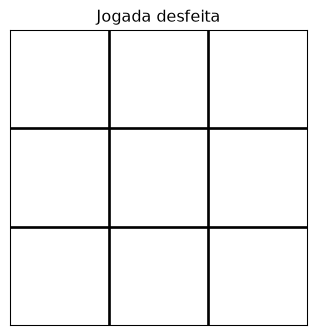

In [12]:
draw_board(board_example, title="Jogada desfeita")

In [13]:
available_actions = get_available_actions(board_example)
print(f"Ações disponíveis: {available_actions}")

Ações disponíveis: [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]

### Função de utilidade e verificação de termino

A seguir, iremos implementar os componentes exigidos para representação
de um algoritmo de busca adversarial, focando obviamente na estrutura do
Minimax. Aqui, implementamos os componentes `IS-TERMINAL` e logo em
seguida traduzimos a identidade do jogador no valor de `UTILITY`.

In [14]:
def utility(board):
    """
    Converte o nome do jogador ('X' ou 'O') para seu valor de utilidade padrão.
    'X' representa o jogador MAX (+1).
    'O' representa o jogador MIN (-1).
    """

    winner = check_winner(board)

    if winner == "X":
        return 1
    if winner == "O":
        return -1
    return 0

In [15]:
def check_winner(board):
    """
    Verifica se há vencedor ou empate.

    Retorna:
    - "X" quando MAX vence;
    - "O" quando MIN vence;
    - "Empate" quando não há mais ações legais;
    - None quando a partida ainda está em andamento.
    """
    # Linhas
    for row_idx in range(len(board)):
        if board[row_idx][0] == board[row_idx][1] == board[row_idx][2] and board[row_idx][0] is not None:
            return board[row_idx][0]

    # Colunas
    for col_idx in range(len(board[0])):
        if board[0][col_idx] == board[1][col_idx] == board[2][col_idx] and board[0][col_idx] is not None:
            return board[0][col_idx]

    # Diagonais
    if board[0][0] == board[1][1] == board[2][2] and board[0][0] is not None:
        return board[0][0]
    if board[0][2] == board[1][1] == board[2][0] and board[0][2] is not None:
        return board[0][2]

    if len(get_available_actions(board)) == 0:
        return "Empate"

    return None


def is_terminal(board):
    """Corresponde ao componente IS-TERMINAL(s)."""
    return check_winner(board) is not None

##### Demonstração

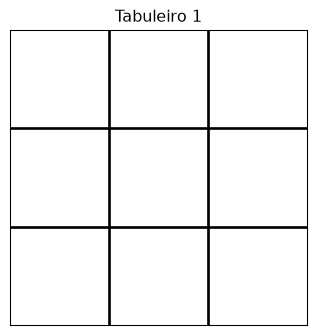

Vencedor obtido: None
Estado terminal? False

In [16]:
# Tabuleiro vazio (sem vencedor e não terminal)
board1 = [
    [None, None, None],
    [None, None, None],
    [None, None, None]
]

winner1 = check_winner(board1)
draw_board(board1, title="Tabuleiro 1")

print(f"Vencedor obtido: {winner1}")
print(f"Estado terminal? {is_terminal(board1)}")

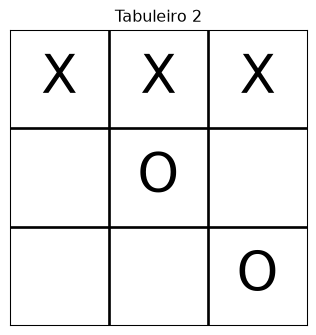

Vencedor obtido: X

In [17]:
# Vencedor na primeira linha (X)
board2 = [
    ['X', 'X', 'X'],
    [None, 'O', None],
    [None, None, 'O']
]

winner2 = check_winner(board2)
draw_board(board2, title="Tabuleiro 2")

print(f"Vencedor obtido: {winner2}")

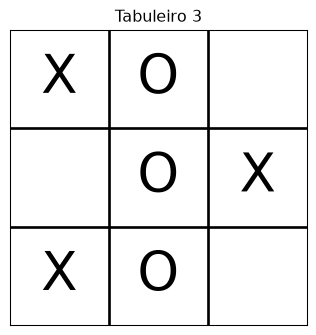

Vencedor obtido: O

In [18]:
# Vencedor na segunda coluna (O)
board3 = [
    ['X', 'O', None],
    [None, 'O', 'X'],
    ['X', 'O', None]
]

winner3 = check_winner(board3)
draw_board(board3, title="Tabuleiro 3")

print(f"Vencedor obtido: {winner3}")

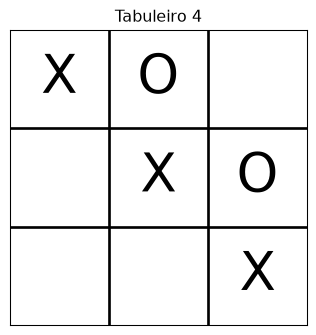

Vencedor obtido: X

In [19]:
# Vencedor na diagonal principal (X)
board4 = [
    ['X', 'O', None],
    [None, 'X', 'O'],
    [None, None, 'X']
]

winner4 = check_winner(board4)
draw_board(board4, title="Tabuleiro 4")

print(f"Vencedor obtido: {winner4}")

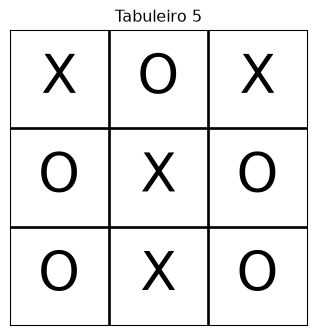

Vencedor obtido: Empate

In [20]:
# Empate (sem vencedor)
board5 = [
    ['X', 'O', 'X'],
    ['O', 'X', 'O'],
    ['O', 'X', 'O']
]

winner6 = check_winner(board5)
draw_board(board5, title="Tabuleiro 5")

print(f"Vencedor obtido: {winner6}")

### Minimax

O algoritmo Minimax opera através de uma **busca recursiva** que simula
o pensamento estratégico: “se eu jogar aqui, qual será a melhor resposta
do meu oponente?”. As funções `max_value` e `min_value` implementam essa
alternância de interesses, onde o algoritmo desce até os estados
terminais para coletar a utilidade e, em seguida, propaga esses valores
de volta para cima. Esse processo de **retropropagação** garante que o
valor atribuído a cada movimento na raiz da árvore considere que ambos
os jogadores farão as melhores escolhas possíveis em cada turno.

#### Função do MAX

In [21]:
def make_search_stats():
    """Cria o registro de métricas usado pelos algoritmos de busca."""
    return {
        "nodes": 0,
        "terminal_tests": 0,
        "max_depth": 0,
        "prunes": 0,
        "alpha_updates": 0,
        "beta_updates": 0,
    }


def update_stats(stats, depth):
    """Atualiza contadores comuns de visita a nós."""
    if stats is not None:
        stats["nodes"] += 1
        stats["max_depth"] = max(stats["max_depth"], depth)


def register_terminal_test(stats):
    if stats is not None:
        stats["terminal_tests"] += 1


def print_search_stats(label, stats):
    """Imprime métricas de busca em formato compacto."""
    print(f"{label}: nós={stats['nodes']}, testes terminais={stats['terminal_tests']}, profundidade máxima={stats['max_depth']}, podas={stats['prunes']}")


def max_value(board, stats=None, depth=0):
    """
    Representa o turno de MAX, isto é, o jogador X.

    MAX quer escolher a ação que produz o maior valor possível.
    """
    update_stats(stats, depth)
    register_terminal_test(stats)

    if is_terminal(board):
        return utility(board)

    best_value = -math.inf

    for action in get_available_actions(board):
        apply_move(board, action, "X")
        value = min_value(board, stats, depth + 1)
        undo_move(board, action)

        best_value = max(best_value, value)

    return best_value

#### Função do MIN

In [22]:
def min_value(board, stats=None, depth=0):
    """
    Representa o turno de MIN, isto é, o jogador O.

    MIN quer escolher a ação que produz o menor valor possível para MAX.
    """
    update_stats(stats, depth)
    register_terminal_test(stats)

    if is_terminal(board):
        return utility(board)

    best_value = math.inf

    for action in get_available_actions(board):
        apply_move(board, action, "O")
        value = max_value(board, stats, depth + 1)
        undo_move(board, action)

        best_value = min(best_value, value)

    return best_value

#### Função de decisão do agente

Diferente das funções recursivas que calculam o valor de estados
futuros, a `get_best_move` é o ponto de decisão final do agente no nó
raiz. Ela funciona como um coordenador que avalia todas as jogadas
legais disponíveis no momento e, baseando-se nos resultados retornados
pelo motor Minimax, seleciona a **ação concreta** que maximiza a
utilidade para o jogador. É nesta etapa que o planejamento teórico se
transforma em uma jogada real executada no tabuleiro.

In [23]:
def get_best_move(board, player, stats=None):
    """
    Retorna a melhor jogada e seu valor Minimax para o jogador atual.
    """
    available_actions = get_available_actions(board)
    if not available_actions:
        return None, utility(board)

    if player == "X":  # MAX
        best_value = -math.inf
        best_move = None

        for action in available_actions:
            apply_move(board, action, "X")
            move_value = min_value(board, stats, depth=1)
            undo_move(board, action)

            if move_value > best_value:
                best_value = move_value
                best_move = action

        return best_move, best_value

    if player == "O":  # MIN
        best_value = math.inf
        best_move = None

        for action in available_actions:
            apply_move(board, action, "O")
            move_value = max_value(board, stats, depth=1)
            undo_move(board, action)

            if move_value < best_value:
                best_value = move_value
                best_move = action

        return best_move, best_value

    raise ValueError("O jogador deve ser 'X' ou 'O'.")

##### Demonstração

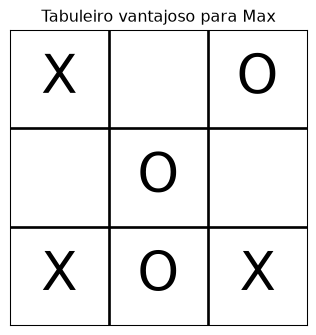

In [24]:
board_max_to_win = [
    ["X", None, "O"],
    [None, "O", None],
    ["X", "O", "X"]
]

draw_board(board_max_to_win, title="Tabuleiro vantajoso para Max")

In [25]:
available_actions = get_available_actions(board_max_to_win)
print(available_actions)

[(0, 1), (1, 0), (1, 2)]

Ação testada por X (MAX): (0, 1)

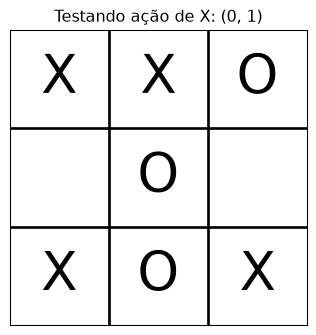

Vencedor após a ação: None
Valor Minimax da ação: 0
Métricas da ação: nós=5, testes terminais=5, profundidade máxima=3, podas=0
Ação testada por X (MAX): (1, 0)

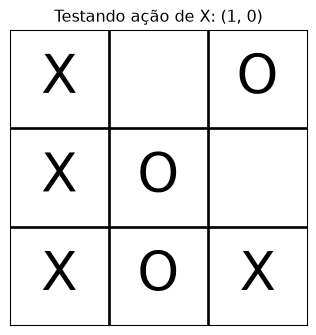

Vencedor após a ação: X
Valor Minimax da ação: 1
Métricas da ação: nós=1, testes terminais=1, profundidade máxima=1, podas=0
Ação testada por X (MAX): (1, 2)

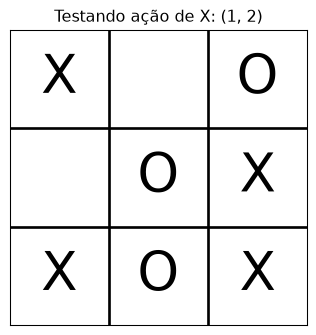

Vencedor após a ação: None
Valor Minimax da ação: -1
Métricas da ação: nós=4, testes terminais=4, profundidade máxima=3, podas=0

In [26]:
for action in available_actions:
    print(f"Ação testada por X (MAX): {action}")

    action_stats = make_search_stats()
    apply_move(board_max_to_win, action, "X")

    winner_after_move = check_winner(board_max_to_win)
    action_value = min_value(board_max_to_win, action_stats, depth=1)

    draw_board(board_max_to_win, title=f"Testando ação de X: {action}")

    print(f"Vencedor após a ação: {winner_after_move}")
    print(f"Valor Minimax da ação: {action_value}")
    print_search_stats("Métricas da ação", action_stats)

    undo_move(board_max_to_win, action)

In [27]:
decision_stats = make_search_stats()
best_move_for_max, best_value_for_max = get_best_move(board_max_to_win, "X", decision_stats)
apply_move(board_max_to_win, best_move_for_max, "X")

print(f"Melhor ação para X (MAX): {best_move_for_max}")
print(f"Valor Minimax da melhor ação: {best_value_for_max}")
print_search_stats("Métricas da decisão", decision_stats)

Melhor ação para X (MAX): (1, 0)
Valor Minimax da melhor ação: 1
Métricas da decisão: nós=10, testes terminais=10, profundidade máxima=3, podas=0

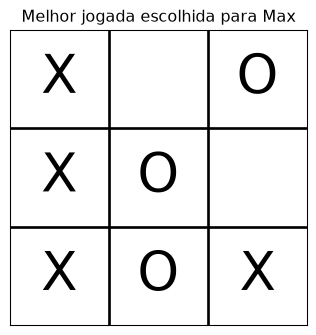

In [28]:
draw_board(board_max_to_win, title="Melhor jogada escolhida para Max")

In [29]:
utility_value = utility(board_max_to_win)
print(f"Utilidade do estado: {utility_value}")
print("Interpretação: +1 significa vitória de X (MAX).")

Utilidade do estado: 1
Interpretação: +1 significa vitória de X (MAX).

### Poda Alpha-Beta

A Poda Alpha-Beta mantém o mesmo valor ótimo do Minimax, mas carrega
dois limites durante a recursão: α, o melhor valor já garantido para
MAX, e β, o melhor valor já garantido para MIN. Quando um ramo não
consegue superar esses limites, ele é descartado sem alterar a decisão
final.

#### Ordenação das ações

In [30]:
def order_actions(actions, action_order="normal"):
    """Retorna ações em ordem normal, reversa ou embaralhada."""
    ordered_actions = list(actions)

    if action_order == "normal":
        return ordered_actions
    if action_order == "reversa":
        return list(reversed(ordered_actions))
    if action_order == "embaralhada":
        random.shuffle(ordered_actions)
        return ordered_actions

    raise ValueError("Use action_order='normal', 'reversa' ou 'embaralhada'.")

A função `order_actions` controla a sequência em que as jogadas legais
são examinadas pela Poda Alpha-Beta. A opção `normal` mantém a ordem
original produzida por `get_available_actions`, `reversa` percorre essa
lista de trás para frente, e `embaralhada` usa uma ordem aleatória. A
decisão ótima deve permanecer equivalente em uma busca completa, mas a
quantidade de podas pode mudar bastante, porque encontrar boas
alternativas cedo torna os limites α e β mais restritivos mais
rapidamente.

Como o killer move acelera a Poda Alpha-Beta?

A técnica do killer move atua como uma estratégia de metaraciocínio que
prioriza a análise de ações com alta probabilidade de sucesso,
impactando a eficiência da IA da seguinte forma:

- Ordenação de Ações: A eficácia da Poda Alpha-Beta depende da sequência
  em que as jogadas são examinadas. O killer move utiliza informações de
  buscas anteriores ou do aprofundamento iterativo para testar primeiro
  as melhores alternativas.

  - Restrição de Limites: Identificar boas jogadas precocemente permite
    atualizar os valores de <b>α</b> (melhor para MAX) e <b>β</b>
    (melhor para MIN) mais rápido, tornando-os mais restritivos e
    facilitando o descarte de sub-ramos irrelevantes.

  - Ganho de Desempenho: Com uma ordenação próxima da ideal, a
    complexidade de busca é reduzida para <i>O(b<sup>m/2</sup>)</i>, o
    que permite ao agente explorar aproximadamente o dobro da
    profundidade em comparação ao Minimax exaustivo.

  - Memória de Busca:</b> A heurística aproveita ameaças e respostas
    eficazes que persistem de turnos passados, evitando o
    reprocessamento desnecessário de ramos inferiores da árvore.

##### Demonstração

In [31]:
order_demo_board = [
    ["X", None, "O"],
    [None, "O", None],
    ["X", None, None],
]

available_actions = get_available_actions(order_demo_board)
print(f"Ações originais: {available_actions}")
print(f"Ordem normal: {order_actions(available_actions, 'normal')}")
print(f"Ordem reversa: {order_actions(available_actions, 'reversa')}")

random.seed("demo-ordenacao")
print(f"Ordem embaralhada: {order_actions(available_actions, 'embaralhada')}")

Ações originais: [(0, 1), (1, 0), (1, 2), (2, 1), (2, 2)]
Ordem normal: [(0, 1), (1, 0), (1, 2), (2, 1), (2, 2)]
Ordem reversa: [(2, 2), (2, 1), (1, 2), (1, 0), (0, 1)]
Ordem embaralhada: [(1, 2), (2, 2), (0, 1), (2, 1), (1, 0)]

#### Função do MAX com Poda Alpha-Beta

In [32]:
def max_value_alpha_beta(board, alpha, beta, stats=None, depth=0, action_order="normal", verbose=False):
    """Valor de um estado em turno de MAX usando poda Alpha-Beta."""
    update_stats(stats, depth)
    register_terminal_test(stats)
    indent = "  " * depth

    if verbose:
        print(f"{indent}MAX(depth={depth}) entra com α={alpha}, β={beta}")

    if is_terminal(board):
        terminal_value = utility(board)
        if verbose:
            print(f"{indent}Estado terminal. UTILITY={terminal_value}")
        return terminal_value

    value = -math.inf

    for action in order_actions(get_available_actions(board), action_order):
        if verbose:
            print(f"{indent}MAX considera ação {action}")

        apply_move(board, action, "X")
        child_value = min_value_alpha_beta(board, alpha, beta, stats, depth + 1, action_order, verbose)
        undo_move(board, action)

        value = max(value, child_value)

        if verbose:
            print(f"{indent}MAX recebeu {child_value}; melhor valor agora é {value}")

        if value >= beta:
            if stats is not None:
                stats["prunes"] += 1
            if verbose:
                print(f"{indent}PODA em MAX: valor {value} >= β {beta}")
            return value

        old_alpha = alpha
        alpha = max(alpha, value)
        if stats is not None and alpha != old_alpha:
            stats["alpha_updates"] += 1
        if verbose and alpha != old_alpha:
            print(f"{indent}MAX atualiza α: {old_alpha} -> {alpha}")

    if verbose:
        print(f"{indent}MAX retorna {value}")
    return value

#### Função do MIN com Poda Alpha-Beta

In [33]:
def min_value_alpha_beta(board, alpha, beta, stats=None, depth=0, action_order="normal", verbose=False):
    """Valor de um estado em turno de MIN usando poda Alpha-Beta."""
    update_stats(stats, depth)
    register_terminal_test(stats)
    indent = "  " * depth

    if verbose:
        print(f"{indent}MIN(depth={depth}) entra com α={alpha}, β={beta}")

    if is_terminal(board):
        terminal_value = utility(board)
        if verbose:
            print(f"{indent}Estado terminal. UTILITY={terminal_value}")
        return terminal_value

    value = math.inf

    for action in order_actions(get_available_actions(board), action_order):
        if verbose:
            print(f"{indent}MIN considera ação {action}")

        apply_move(board, action, "O")
        child_value = max_value_alpha_beta(board, alpha, beta, stats, depth + 1, action_order, verbose)
        undo_move(board, action)

        value = min(value, child_value)

        if verbose:
            print(f"{indent}MIN recebeu {child_value}; melhor valor agora é {value}")

        if value <= alpha:
            if stats is not None:
                stats["prunes"] += 1
            if verbose:
                print(f"{indent}PODA em MIN: valor {value} <= α {alpha}")
            return value

        old_beta = beta
        beta = min(beta, value)
        if stats is not None and beta != old_beta:
            stats["beta_updates"] += 1
        if verbose and beta != old_beta:
            print(f"{indent}MIN atualiza β: {old_beta} -> {beta}")

    if verbose:
        print(f"{indent}MIN retorna {value}")
    return value

#### Função de decisão com Poda Alpha-Beta

In [34]:
def get_best_move_alpha_beta(board, player, stats=None, action_order="normal", verbose=False):
    """Retorna a melhor jogada usando Alpha-Beta e seu valor."""
    available_actions = order_actions(get_available_actions(board), action_order)
    if not available_actions:
        return None, utility(board)

    alpha = -math.inf
    beta = math.inf

    if verbose:
        print(f"Jogador na raiz: {player}")
        print(f"Ordem das ações: {action_order}")
        print(f"α inicial: {alpha}")
        print(f"β inicial: {beta}")

    if player == "X":
        best_value = -math.inf
        best_move = None

        for action in available_actions:
            if verbose:
                print()
                print(f"RAIZ/MAX testa ação {action}")
                print(f"Antes da ação: α={alpha}, β={beta}")

            apply_move(board, action, "X")
            move_value = min_value_alpha_beta(board, alpha, beta, stats, depth=1, action_order=action_order, verbose=verbose)
            undo_move(board, action)

            if move_value > best_value:
                best_value = move_value
                best_move = action

            old_alpha = alpha
            alpha = max(alpha, best_value)
            if stats is not None and alpha != old_alpha:
                stats["alpha_updates"] += 1

            if verbose:
                print(f"RAIZ/MAX recebeu {move_value}")
                if alpha != old_alpha:
                    print(f"RAIZ/MAX atualiza α: {old_alpha} -> {alpha}")
                else:
                    print(f"RAIZ/MAX mantém α={alpha}")
                print(f"Melhor ação parcial: {best_move}, valor={best_value}")

        return best_move, best_value

    if player == "O":
        best_value = math.inf
        best_move = None

        for action in available_actions:
            if verbose:
                print()
                print(f"RAIZ/MIN testa ação {action}")
                print(f"Antes da ação: α={alpha}, β={beta}")

            apply_move(board, action, "O")
            move_value = max_value_alpha_beta(board, alpha, beta, stats, depth=1, action_order=action_order, verbose=verbose)
            undo_move(board, action)

            if move_value < best_value:
                best_value = move_value
                best_move = action

            old_beta = beta
            beta = min(beta, best_value)
            if stats is not None and beta != old_beta:
                stats["beta_updates"] += 1

            if verbose:
                print(f"RAIZ/MIN recebeu {move_value}")
                if beta != old_beta:
                    print(f"RAIZ/MIN atualiza β: {old_beta} -> {beta}")
                else:
                    print(f"RAIZ/MIN mantém β={beta}")
                print(f"Melhor ação parcial: {best_move}, valor={best_value}")

        return best_move, best_value

    raise ValueError("O jogador deve ser 'X' ou 'O'.")

##### Demonstração

Estado próximo do fim do jogo:
X (MAX) joga agora. Há poucas ações legais, então conseguimos acompanhar cada teste.

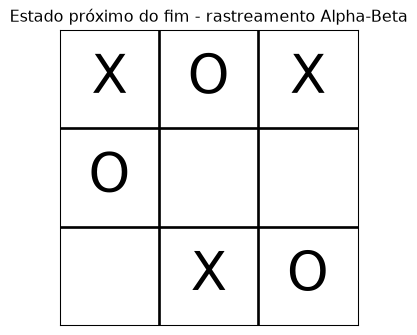

Jogador na raiz: X
Ordem das ações: normal
α inicial: -inf
β inicial: inf

RAIZ/MAX testa ação (1, 1)
Antes da ação: α=-inf, β=inf
  MIN(depth=1) entra com α=-inf, β=inf
  MIN considera ação (1, 2)
    MAX(depth=2) entra com α=-inf, β=inf
    MAX considera ação (2, 0)
      MIN(depth=3) entra com α=-inf, β=inf
      Estado terminal. UTILITY=1
    MAX recebeu 1; melhor valor agora é 1
    MAX atualiza α: -inf -> 1
    MAX retorna 1
  MIN recebeu 1; melhor valor agora é 1
  MIN atualiza β: inf -> 1
  MIN considera ação (2, 0)
    MAX(depth=2) entra com α=-inf, β=1
    MAX considera ação (1, 2)
      MIN(depth=3) entra com α=-inf, β=1
      Estado terminal. UTILITY=0
    MAX recebeu 0; melhor valor agora é 0
    MAX atualiza α: -inf -> 0
    MAX retorna 0
  MIN recebeu 0; melhor valor agora é 0
  MIN atualiza β: 1 -> 0
  MIN retorna 0
RAIZ/MAX recebeu 0
RAIZ/MAX atualiza α: -inf -> 0
Melhor ação parcial: (1, 1), valor=0

RAIZ/MAX testa ação (1, 2)
Antes da ação: α=0, β=inf
  MIN(depth=1) 

In [35]:
trace_board = [
    ["X", "O", "X"],
    ["O", None, None],
    [None, "X", "O"],
]

print("Estado próximo do fim do jogo:")
print("X (MAX) joga agora. Há poucas ações legais, então conseguimos acompanhar cada teste.")
draw_board(trace_board, title="Estado próximo do fim - rastreamento Alpha-Beta")

best_trace_move, best_trace_value = get_best_move_alpha_beta(
    trace_board,
    player="X",
    action_order="normal",
    verbose=True,
)

print()
print(f"Ação escolhida no rastreamento: {best_trace_move}")
print(f"Valor da ação escolhida: {best_trace_value}")

Aplicando a jogada escolhida no rastreamento:
X joga (1, 1) (valor minimax=0)

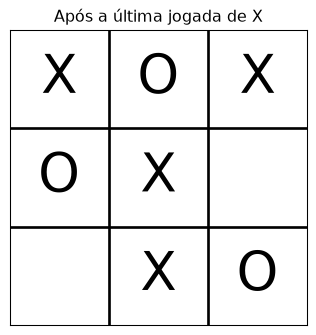


Jogada 2: O escolhe (2, 0) (valor minimax=0)
Métricas da jogada 2: nós=4, testes terminais=4, profundidade máxima=2, podas=0

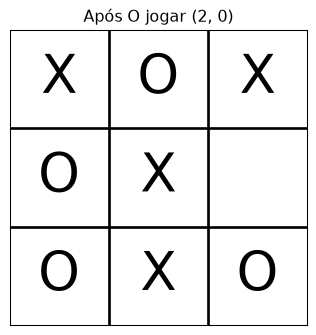


Jogada 3: X escolhe (1, 2) (valor minimax=0)
Métricas da jogada 3: nós=1, testes terminais=1, profundidade máxima=1, podas=0

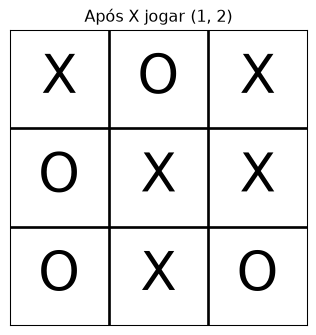


Resultado final a partir do rastreamento: empate

In [36]:
continued_board = [row[:] for row in trace_board]

print("Aplicando a jogada escolhida no rastreamento:")
print(f"X joga {best_trace_move} (valor minimax={best_trace_value})")
apply_move(continued_board, best_trace_move, "X")
draw_board(continued_board, title="Após a última jogada de X")

current_player = "O"
turn = 2

while not is_terminal(continued_board):
    turn_stats = make_search_stats()
    move, value = get_best_move_alpha_beta(
        continued_board,
        player=current_player,
        stats=turn_stats,
        action_order="normal",
    )

    print()
    print(f"Jogada {turn}: {current_player} escolhe {move} (valor minimax={value})")
    print_search_stats(f"Métricas da jogada {turn}", turn_stats)

    apply_move(continued_board, move, current_player)
    draw_board(continued_board, title=f"Após {current_player} jogar {move}")

    current_player = "O" if current_player == "X" else "X"
    turn += 1

winner = check_winner(continued_board)
result = "empate" if winner == "Empate" else f"vitória de {winner}"
print()
print(f"Resultado final a partir do rastreamento: {result}")

### Busca Heurística (H-Minimax)

O H-Minimax usa um teste de corte para interromper a busca em uma
profundidade fixa. Quando o estado ainda não é terminal, a função
`evaluate_board` estima a utilidade com base nos **alinhamentos
vencedores** do tabuleiro: horizontais, verticais e diagonais.

#### Simplificando tabuleiro para avaliação

In [37]:
def get_winning_alignments(board):
    """Retorna todos os alinhamentos possíveis de vitória: horizontais, verticais e diagonais."""
    alignments = []

    # Horizontais
    alignments.extend(board)

    # Verticais
    alignments.extend([[board[row_idx][col_idx] for row_idx in range(3)] for col_idx in range(3)])

    # Diagonais
    alignments.append([board[0][0], board[1][1], board[2][2]])
    alignments.append([board[0][2], board[1][1], board[2][0]])

    return alignments

In [38]:
def evaluate_alignment(alignment):
    """Avalia um alinhamento possível de vitória do ponto de vista de X (MAX)."""
    x_count = alignment.count("X")
    o_count = alignment.count("O")
    empty_count = alignment.count(None)

    if x_count > 0 and o_count > 0:
        return 0
    if x_count == 2 and empty_count == 1:
        return 10
    if o_count == 2 and empty_count == 1:
        return -10
    if x_count == 1 and empty_count == 2:
        return 1
    if o_count == 1 and empty_count == 2:
        return -1
    return 0

##### Demonstração

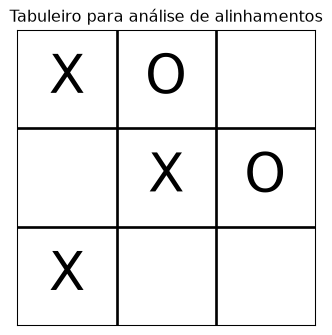

In [39]:
simplified_board = [
    ['X', 'O', None],
    [None, 'X', 'O'],
    ['X', None, None]
]

draw_board(simplified_board, title="Tabuleiro para análise de alinhamentos")

In [40]:
simplified_board = get_winning_alignments(simplified_board)
print(simplified_board)

[['X', 'O', None], [None, 'X', 'O'], ['X', None, None], ['X', None, 'X'], ['O', 'X', None], [None, 'O', None], ['X', 'X', None], [None, 'X', 'X']]

In [41]:
for alignment in simplified_board:
    print(f"Alinhamento {alignment} -> pontuação {evaluate_alignment(alignment)}")

Alinhamento ['X', 'O', None] -> pontuação 0
Alinhamento [None, 'X', 'O'] -> pontuação 0
Alinhamento ['X', None, None] -> pontuação 1
Alinhamento ['X', None, 'X'] -> pontuação 10
Alinhamento ['O', 'X', None] -> pontuação 0
Alinhamento [None, 'O', None] -> pontuação -1
Alinhamento ['X', 'X', None] -> pontuação 10
Alinhamento [None, 'X', 'X'] -> pontuação 10

A pontuação é calculada sempre do ponto de vista de **X (MAX)**.
Alinhamentos promissores para X recebem valores positivos, alinhamentos
perigosos para O recebem valores negativos, e alinhamentos bloqueados
pelos dois jogadores recebem `0`, pois não podem mais formar vitória
para nenhum lado. Usamos `10` e `-10` para ameaças imediatas com duas
marcas e uma casa vazia, e `1` ou `-1` para oportunidades ainda fracas.

#### Função de Avaliação Heurística (EVAL)

In [42]:
def evaluate_board(board):
    """
    Estima a utilidade de estados não terminais.

    Estados terminais continuam usando UTILITY.
    """
    if is_terminal(board):
        return utility(board) * 100

    return sum(evaluate_alignment(alignment) for alignment in get_winning_alignments(board))

#### Teste de corte

In [43]:
def cutoff_test(board, depth, depth_limit):
    """Interrompe a busca em estado terminal ou no limite de profundidade."""
    return is_terminal(board) or depth >= depth_limit

#### Função do MAX com H-Minimax

In [44]:
def max_value_h_minimax(board, depth, depth_limit, stats=None):
    """Valor heurístico de um estado em turno de MAX."""
    update_stats(stats, depth)
    register_terminal_test(stats)

    if cutoff_test(board, depth, depth_limit):
        return evaluate_board(board)

    best_value = -math.inf

    for action in get_available_actions(board):
        apply_move(board, action, "X")
        value = min_value_h_minimax(board, depth + 1, depth_limit, stats)
        undo_move(board, action)
        best_value = max(best_value, value)

    return best_value

#### Função do MIN com H-Minimax

In [45]:
def min_value_h_minimax(board, depth, depth_limit, stats=None):
    """Valor heurístico de um estado em turno de MIN."""
    update_stats(stats, depth)
    register_terminal_test(stats)

    if cutoff_test(board, depth, depth_limit):
        return evaluate_board(board)

    best_value = math.inf

    for action in get_available_actions(board):
        apply_move(board, action, "O")
        value = max_value_h_minimax(board, depth + 1, depth_limit, stats)
        undo_move(board, action)
        best_value = min(best_value, value)

    return best_value

#### Função de decisão com H-Minimax

In [46]:
def get_best_move_h_minimax(board, player, depth_limit, stats=None):
    """Retorna a melhor jogada usando H-Minimax em profundidade limitada."""
    available_actions = get_available_actions(board)
    if not available_actions:
        return None, evaluate_board(board)

    if player == "X":
        best_value = -math.inf
        best_move = None

        for action in available_actions:
            apply_move(board, action, "X")
            move_value = min_value_h_minimax(board, 1, depth_limit, stats)
            undo_move(board, action)

            if move_value > best_value:
                best_value = move_value
                best_move = action

        return best_move, best_value

    if player == "O":
        best_value = math.inf
        best_move = None

        for action in available_actions:
            apply_move(board, action, "O")
            move_value = max_value_h_minimax(board, 1, depth_limit, stats)
            undo_move(board, action)

            if move_value < best_value:
                best_value = move_value
                best_move = action

        return best_move, best_value

    raise ValueError("O jogador deve ser 'X' ou 'O'.")

### Função para simular partida

Nesta etapa final, integramos todos os componentes desenvolvidos para
observar o agente em ação. A função de simulação coordena a alternância
de turnos (**TO-MOVE**) e aplica a decisão ótima calculada pelo motor de
busca em cada estado. Aqui, validamos se o comportamento baseado em
utilidade resulta na estratégia imbatível esperada, permitindo
acompanhar o fluxo completo da partida — do estado inicial até o teste
terminal (**IS-TERMINAL**) — e verificar se a IA consegue antecipar as
jogadas do oponente para garantir o melhor desfecho possível.

#### Adaptadores para variantes de Minimax

In [47]:
def minimax_strategy(board, player, stats, depth_limit=None, action_order="normal"):
    """Adaptador para usar Minimax padrão dentro de play_game."""
    return get_best_move(board, player, stats)


def alpha_beta_strategy(board, player, stats, depth_limit=None, action_order="normal"):
    """Adaptador para usar Poda Alpha-Beta dentro de play_game."""
    return get_best_move_alpha_beta(board, player, stats, action_order)


def h_minimax_strategy(board, player, stats, depth_limit=2, action_order="normal"):
    """Adaptador para usar H-Minimax dentro de play_game."""
    return get_best_move_h_minimax(board, player, depth_limit, stats)

#### Registro das variantes de busca

In [48]:
SEARCH_VARIANTS = {
    "minimax": {
        "label": "Minimax Padrão",
        "strategy": minimax_strategy,
    },
    "alpha_beta": {
        "label": "Poda Alpha-Beta",
        "strategy": alpha_beta_strategy,
    },
    "h_minimax": {
        "label": "H-Minimax",
        "strategy": h_minimax_strategy,
    },
}

#### Resumo das métricas da partida

In [49]:
def summarize_history(history):
    """Resume métricas acumuladas de uma partida."""
    total_stats = make_search_stats()

    for turn in history:
        for key in total_stats:
            if key == "max_depth":
                total_stats[key] = max(total_stats[key], turn["stats"].get(key, 0))
            else:
                total_stats[key] += turn["stats"].get(key, 0)

    return total_stats

#### Orquestrador de partida

In [50]:
def play_game(board=None, player="X", variant="minimax", depth_limit=2, action_order="normal", use_visualization=False):
    """
    Orquestra uma partida completa usando uma das variantes do Minimax.

    Parâmetros principais:
    - variant="minimax": busca exaustiva até estados terminais;
    - variant="alpha_beta": busca exaustiva com Poda Alpha-Beta;
    - variant="h_minimax": busca heurística com limite de profundidade.
    """
    if variant not in SEARCH_VARIANTS:
        valid_variants = ", ".join(SEARCH_VARIANTS.keys())
        raise ValueError(f"Variante inválida. Use uma destas opções: {valid_variants}")

    current_board = create_board() if board is None else copy.deepcopy(board)
    current_player = player
    turn = 1
    history = []

    variant_info = SEARCH_VARIANTS[variant]
    strategy = variant_info["strategy"]
    variant_label = variant_info["label"]

    player_labels = {
        "X": "X (MAX)",
        "O": "O (MIN)",
    }

    print(f"Iniciando partida com {variant_label} (X = MAX, O = MIN):")
    if variant == "h_minimax":
        print(f"Limite de profundidade: {depth_limit}")
    if variant == "alpha_beta":
        print(f"Ordem das ações: {action_order}")

    if use_visualization:
        draw_board(current_board, title="Estado inicial")

    while not is_terminal(current_board):
        player_label = player_labels[current_player]
        turn_stats = make_search_stats()
        move, move_value = strategy(current_board, current_player, turn_stats, depth_limit, action_order)

        print(f"Turno {turn} - {player_label}")
        print(f"Ação escolhida: {move}")
        print(f"Valor da ação: {move_value}")
        print_search_stats("Métricas da busca", turn_stats)

        apply_move(current_board, move, current_player)

        history.append({
            "turn": turn,
            "player": current_player,
            "move": move,
            "value": move_value,
            "stats": turn_stats,
            "board": copy.deepcopy(current_board),
        })

        if use_visualization:
            draw_board(current_board, title=f"{variant_label} - turno {turn}: {player_label}")

        current_player = "O" if current_player == "X" else "X"
        turn += 1

    winner = check_winner(current_board)
    if winner == "X":
        print("Fim de jogo: X (MAX) venceu")
    elif winner == "O":
        print("Fim de jogo: O (MIN) venceu")
    else:
        print("Fim de jogo: Empate")

    total_stats = summarize_history(history)
    print_search_stats("Métricas acumuladas da partida", total_stats)

    return current_board, winner, history

## Exemplo prático

### Cenário 1 - Minimax Padrão (Busca Exaustiva)

No **Cenário 1**, aplicamos tudo o que foi construído em uma simulação
prática de partida completa. O objetivo é observar o comportamento dos
agentes em tempo real, visualizando como a IA decide cada movimento a
partir de um estado específico. Este cenário permite testar a eficácia
da árvore de jogo e verificar se o algoritmo consegue garantir
resultados ótimos (como o empate forçado no Jogo da Velha), demonstrando
a transição de um agente baseado em objetivos para um **agente baseado
em utilidade**.

Iniciando partida com Minimax Padrão (X = MAX, O = MIN):

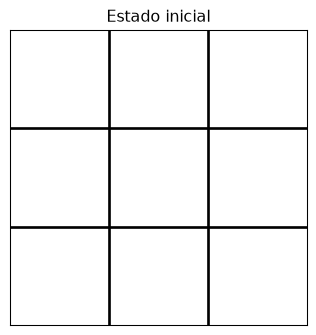

Turno 1 - X (MAX)
Ação escolhida: (0, 0)
Valor da ação: 0
Métricas da busca: nós=549945, testes terminais=549945, profundidade máxima=9, podas=0

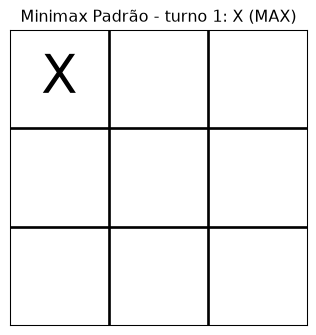

Turno 2 - O (MIN)
Ação escolhida: (1, 1)
Valor da ação: 0
Métricas da busca: nós=59704, testes terminais=59704, profundidade máxima=8, podas=0

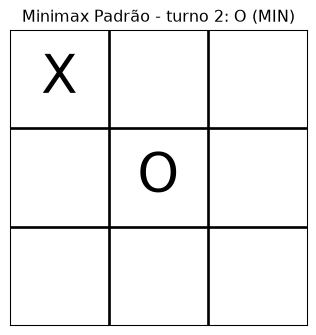

Turno 3 - X (MAX)
Ação escolhida: (0, 1)
Valor da ação: 0
Métricas da busca: nós=7331, testes terminais=7331, profundidade máxima=7, podas=0

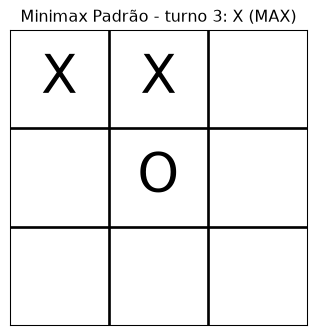

Turno 4 - O (MIN)
Ação escolhida: (0, 2)
Valor da ação: 0
Métricas da busca: nós=934, testes terminais=934, profundidade máxima=6, podas=0

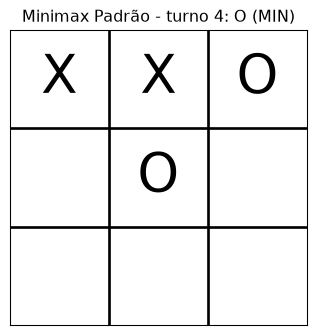

Turno 5 - X (MAX)
Ação escolhida: (2, 0)
Valor da ação: 0
Métricas da busca: nós=197, testes terminais=197, profundidade máxima=5, podas=0

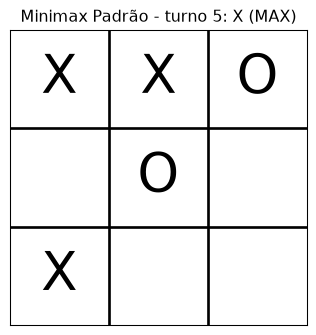

Turno 6 - O (MIN)
Ação escolhida: (1, 0)
Valor da ação: 0
Métricas da busca: nós=46, testes terminais=46, profundidade máxima=4, podas=0

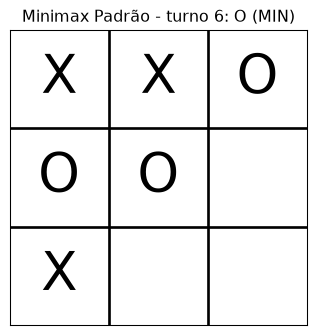

Turno 7 - X (MAX)
Ação escolhida: (1, 2)
Valor da ação: 0
Métricas da busca: nós=13, testes terminais=13, profundidade máxima=3, podas=0

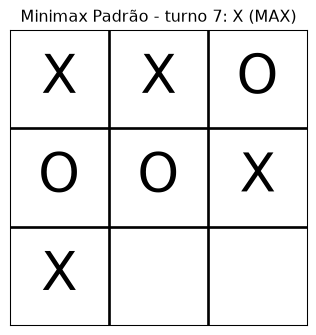

Turno 8 - O (MIN)
Ação escolhida: (2, 1)
Valor da ação: 0
Métricas da busca: nós=4, testes terminais=4, profundidade máxima=2, podas=0

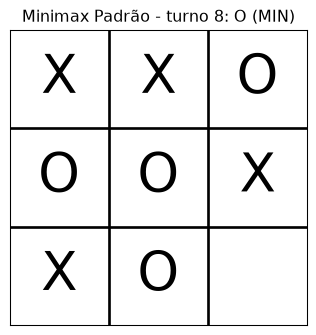

Turno 9 - X (MAX)
Ação escolhida: (2, 2)
Valor da ação: 0
Métricas da busca: nós=1, testes terminais=1, profundidade máxima=1, podas=0

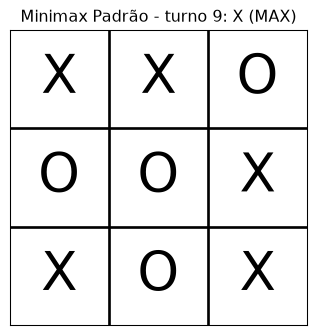

Fim de jogo: Empate
Métricas acumuladas da partida: nós=618175, testes terminais=618175, profundidade máxima=9, podas=0
Resultado final do Cenário 1: Empate

In [51]:
final_board_minimax, winner_minimax, history_minimax = play_game(
    board=create_board(),
    player="X",
    variant="minimax",
    use_visualization=True,
)

print(f"Resultado final do Cenário 1: {winner_minimax}")

Por que o Minimax padrão consegue garantir empate no Jogo da Velha
quando os dois jogadores usam a mesma estratégia ótima?

Porque ele explora a árvore de jogo até estados terminais e escolhe
ações assumindo que o adversário também responderá da melhor forma
possível. No Jogo da Velha, esse raciocínio completo leva ao empate
quando ambos jogam perfeitamente.

### Cenário 2 - Otimização com Poda Alpha-Beta

No **Cenário 2**, mantemos a mesma decisão ótima do Minimax, mas
evitamos explorar ramos que não podem alterar a escolha feita na raiz.
Os parâmetros α e β guardam, respectivamente, o melhor valor já
garantido por MAX e o melhor valor já garantido por MIN. Quando um ramo
não consegue melhorar a decisão de quem já tem uma alternativa melhor,
ele é podado.

Iniciando partida com Poda Alpha-Beta (X = MAX, O = MIN):
Ordem das ações: normal

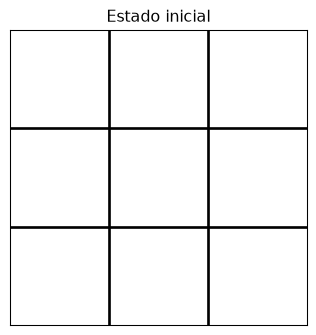

Turno 1 - X (MAX)
Ação escolhida: (0, 0)
Valor da ação: 0
Métricas da busca: nós=18296, testes terminais=18296, profundidade máxima=9, podas=8180

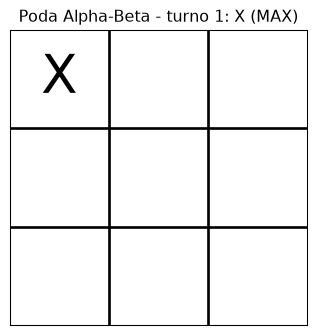

Turno 2 - O (MIN)
Ação escolhida: (1, 1)
Valor da ação: 0
Métricas da busca: nós=2337, testes terminais=2337, profundidade máxima=8, podas=1014

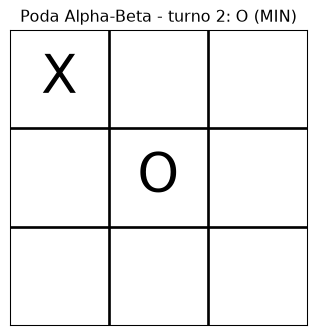

Turno 3 - X (MAX)
Ação escolhida: (0, 1)
Valor da ação: 0
Métricas da busca: nós=843, testes terminais=843, profundidade máxima=7, podas=344

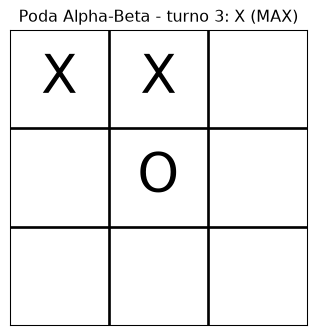

Turno 4 - O (MIN)
Ação escolhida: (0, 2)
Valor da ação: 0
Métricas da busca: nós=74, testes terminais=74, profundidade máxima=6, podas=29

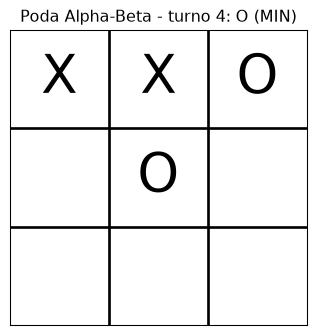

Turno 5 - X (MAX)
Ação escolhida: (2, 0)
Valor da ação: 0
Métricas da busca: nós=63, testes terminais=63, profundidade máxima=5, podas=24

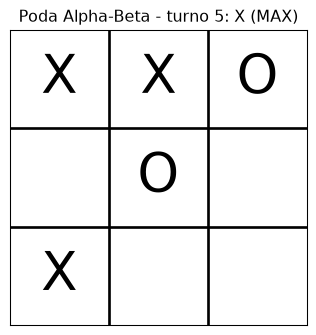

Turno 6 - O (MIN)
Ação escolhida: (1, 0)
Valor da ação: 0
Métricas da busca: nós=16, testes terminais=16, profundidade máxima=4, podas=6

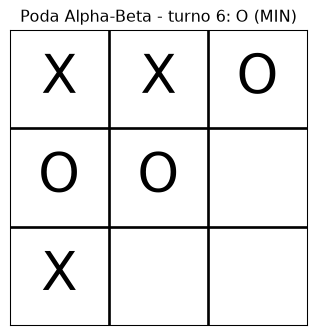

Turno 7 - X (MAX)
Ação escolhida: (1, 2)
Valor da ação: 0
Métricas da busca: nós=9, testes terminais=9, profundidade máxima=3, podas=3

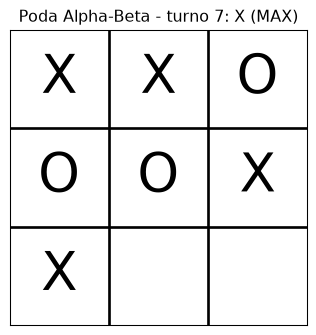

Turno 8 - O (MIN)
Ação escolhida: (2, 1)
Valor da ação: 0
Métricas da busca: nós=4, testes terminais=4, profundidade máxima=2, podas=1

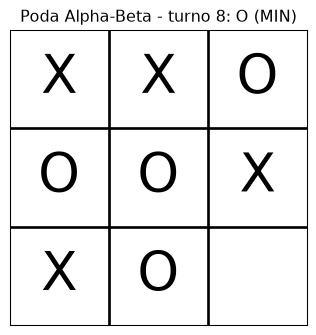

Turno 9 - X (MAX)
Ação escolhida: (2, 2)
Valor da ação: 0
Métricas da busca: nós=1, testes terminais=1, profundidade máxima=1, podas=0

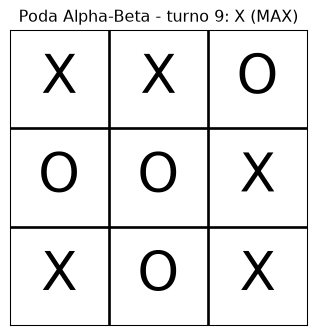

Fim de jogo: Empate
Métricas acumuladas da partida: nós=21643, testes terminais=21643, profundidade máxima=9, podas=9601
Resultado final do Cenário 2: Empate

In [52]:
final_board_alpha_beta, winner_alpha_beta, history_alpha_beta = play_game(
    board=create_board(),
    player="X",
    variant="alpha_beta",
    use_visualization=True,
)

print(f"Resultado final do Cenário 2: {winner_alpha_beta}")

Por que uma poda é considerada segura?

Porque o algoritmo já encontrou uma alternativa melhor para um jogador
anterior na árvore. Assim, aquele ramo não será escolhido por um jogador
racional.

### Cenário 3 - Poda Alpha-Beta com ordem reversa

Neste cenário, mantemos a Poda Alpha-Beta, mas avaliamos as ações legais
na ordem inversa. O objetivo é observar que a ordem de exploração pode
alterar a quantidade de nós visitados e podas realizadas, mesmo quando a
lógica da decisão ótima continua a mesma.

In [53]:
final_board_alpha_beta_reverse, winner_alpha_beta_reverse, history_alpha_beta_reverse = play_game(
    board=create_board(),
    player="X",
    variant="alpha_beta",
    action_order="reversa",
    use_visualization=False,
)

reverse_stats = summarize_history(history_alpha_beta_reverse)
print(f"Resultado final do Cenário 3: {winner_alpha_beta_reverse}")
print_search_stats("Métricas com ordem reversa", reverse_stats)

Iniciando partida com Poda Alpha-Beta (X = MAX, O = MIN):
Ordem das ações: reversa
Turno 1 - X (MAX)
Ação escolhida: (2, 2)
Valor da ação: 0
Métricas da busca: nós=18296, testes terminais=18296, profundidade máxima=9, podas=8180
Turno 2 - O (MIN)
Ação escolhida: (1, 1)
Valor da ação: 0
Métricas da busca: nós=2337, testes terminais=2337, profundidade máxima=8, podas=1014
Turno 3 - X (MAX)
Ação escolhida: (2, 1)
Valor da ação: 0
Métricas da busca: nós=843, testes terminais=843, profundidade máxima=7, podas=344
Turno 4 - O (MIN)
Ação escolhida: (2, 0)
Valor da ação: 0
Métricas da busca: nós=74, testes terminais=74, profundidade máxima=6, podas=29
Turno 5 - X (MAX)
Ação escolhida: (0, 2)
Valor da ação: 0
Métricas da busca: nós=63, testes terminais=63, profundidade máxima=5, podas=24
Turno 6 - O (MIN)
Ação escolhida: (1, 2)
Valor da ação: 0
Métricas da busca: nós=16, testes terminais=16, profundidade máxima=4, podas=6
Turno 7 - X (MAX)
Ação escolhida: (1, 0)
Valor da ação: 0
Métricas da bus

Por que a ordem reversa pode alterar o número de podas?

A Poda Alpha-Beta depende dos limites α e β acumulados durante a busca.
Se a ordem reversa encontrar boas alternativas mais cedo ou mais tarde
que a ordem normal, esses limites serão atualizados em momentos
diferentes, alterando a quantidade de ramos descartados.

### Cenário 4 - Poda Alpha-Beta com ordem embaralhada

Neste cenário, avaliamos as ações em ordem embaralhada. Usamos uma
semente fixa para que o experimento seja reprodutível e os alunos possam
comparar os resultados entre execuções.

In [54]:
#random.seed("alpha-beta-ordem")

final_board_alpha_beta_random, winner_alpha_beta_random, history_alpha_beta_random = play_game(
    board=create_board(),
    player="X",
    variant="alpha_beta",
    action_order="embaralhada",
    use_visualization=False,
)

random_stats = summarize_history(history_alpha_beta_random)
print(f"Resultado final do Cenário 4: {winner_alpha_beta_random}")
print_search_stats("Métricas com ordem embaralhada", random_stats)

Iniciando partida com Poda Alpha-Beta (X = MAX, O = MIN):
Ordem das ações: embaralhada
Turno 1 - X (MAX)
Ação escolhida: (0, 1)
Valor da ação: 0
Métricas da busca: nós=17269, testes terminais=17269, profundidade máxima=9, podas=7639
Turno 2 - O (MIN)
Ação escolhida: (0, 0)
Valor da ação: 0
Métricas da busca: nós=2899, testes terminais=2899, profundidade máxima=8, podas=1274
Turno 3 - X (MAX)
Ação escolhida: (1, 0)
Valor da ação: 0
Métricas da busca: nós=1366, testes terminais=1366, profundidade máxima=7, podas=548
Turno 4 - O (MIN)
Ação escolhida: (1, 1)
Valor da ação: 0
Métricas da busca: nós=352, testes terminais=352, profundidade máxima=6, podas=139
Turno 5 - X (MAX)
Ação escolhida: (2, 2)
Valor da ação: 0
Métricas da busca: nós=91, testes terminais=91, profundidade máxima=5, podas=30
Turno 6 - O (MIN)
Ação escolhida: (2, 0)
Valor da ação: 0
Métricas da busca: nós=32, testes terminais=32, profundidade máxima=4, podas=10
Turno 7 - X (MAX)
Ação escolhida: (0, 2)
Valor da ação: 0
Métri

Por que usamos `random.seed` antes da ordem embaralhada?

A ordem embaralhada depende de aleatoriedade. A semente fixa permite
reproduzir a mesma sequência de ações em execuções diferentes, tornando
a comparação mais justa e verificável.

### Cenário 5 - Busca Heurística (H-Minimax)

No **Cenário 5**, interrompemos a busca antes de chegar obrigatoriamente
ao fim da partida. Quando o limite de profundidade é atingido, usamos
uma função de avaliação (`EVAL`) para estimar a utilidade do estado.
Essa aproximação permite trabalhar com jogos maiores, mas pode produzir
decisões ruins quando uma ameaça importante aparece logo depois do
limite de busca, fenômeno conhecido como **efeito horizonte**.

Iniciando partida com H-Minimax (X = MAX, O = MIN):
Limite de profundidade: 2

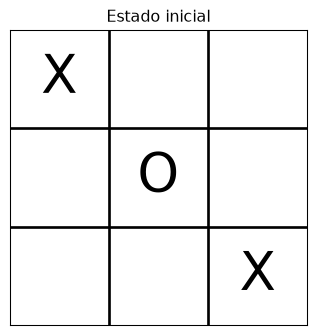

Turno 1 - O (MIN)
Ação escolhida: (0, 1)
Valor da ação: 10
Métricas da busca: nós=36, testes terminais=36, profundidade máxima=2, podas=0

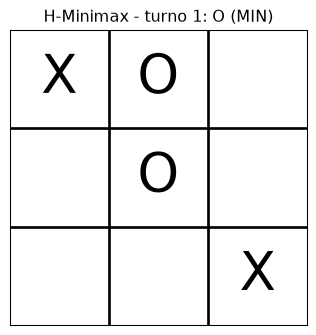

Turno 2 - X (MAX)
Ação escolhida: (2, 1)
Valor da ação: -10
Métricas da busca: nós=25, testes terminais=25, profundidade máxima=2, podas=0

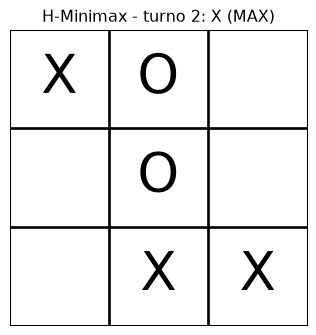

Turno 3 - O (MIN)
Ação escolhida: (2, 0)
Valor da ação: 9
Métricas da busca: nós=16, testes terminais=16, profundidade máxima=2, podas=0

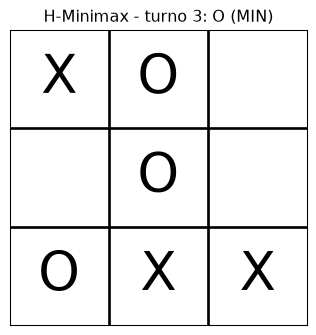

Turno 4 - X (MAX)
Ação escolhida: (0, 2)
Valor da ação: -10
Métricas da busca: nós=9, testes terminais=9, profundidade máxima=2, podas=0

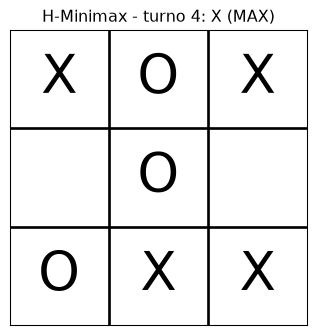

Turno 5 - O (MIN)
Ação escolhida: (1, 2)
Valor da ação: 0
Métricas da busca: nós=4, testes terminais=4, profundidade máxima=2, podas=0

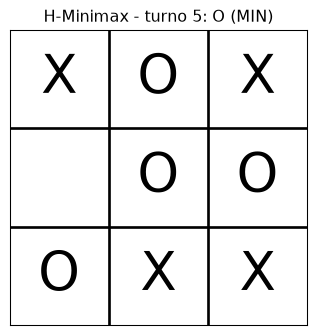

Turno 6 - X (MAX)
Ação escolhida: (1, 0)
Valor da ação: 0
Métricas da busca: nós=1, testes terminais=1, profundidade máxima=1, podas=0

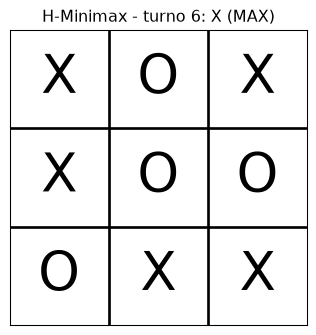

Fim de jogo: Empate
Métricas acumuladas da partida: nós=91, testes terminais=91, profundidade máxima=2, podas=0

In [55]:
horizon_board = [
    ["X", None, None],
    [None, "O", None],
    [None, None, "X"],
]

final_board_h_minimax, winner_h_minimax, history_h_minimax = play_game(
    board=horizon_board,
    player="O",
    variant="h_minimax",
    depth_limit=2,
    use_visualization=True,
)

Por que o H-Minimax pode tomar uma decisão pior que o Minimax exaustivo?

O **H-Minimax** pode tomar decisões piores que o **Minimax exaustivo**
porque ele não explora a árvore de jogo até os estados terminais,
utilizando, em vez disso, um **teste de corte** e uma **função de
avaliação heurística (EVAL)** que funciona apenas como uma estimativa
falível das chances de vitória. Essa limitação de profundidade torna o
algoritmo vulnerável ao **“Efeito Horizonte”**, um fenômeno em que o
agente enfrenta uma ameaça inevitável e prejudicial, mas escolhe
movimentos que apenas a adiam temporariamente, “empurrando” o dano para
além do limite de busca da IA. Diferente do Minimax exaustivo, que
identifica a utilidade real e absoluta do fim da partida, o H-Minimax
pode ser induzido a realizar sacrifícios inúteis de recursos na crença
errônea de que salvou sua posição, quando na verdade apenas ocultou
momentaneamente o desfecho negativo de seu horizonte de visão limitado.

A função `EVAL` precisa ser perfeita?

Não. Ela é uma aproximação. Porém, quanto melhor ela representar
oportunidades e ameaças reais do jogo, melhores tendem a ser as decisões
do agente.

## Desafios

Ajustando a heurística: Altere a função `evaluate_alignment` para
valorizar também o controle do centro do tabuleiro. Em seguida, execute
novamente o Cenário 5 e observe se a escolha do H-Minimax muda.

Sugestões para investigação:

1.  Adicione um pequeno bônus quando `board[1][1] == "X"`.
2.  Adicione uma pequena penalização quando `board[1][1] == "O"`.
3.  Compare os resultados com `depth_limit=1`, `depth_limit=2` e
    `depth_limit=3`.
4.  Explique se a mudança melhorou, piorou ou apenas alterou o
    comportamento do agente.

## Key Takeaways

- O Minimax padrão busca até estados terminais e, no Jogo da Velha,
  permite observar o empate forçado quando ambos os agentes jogam de
  forma ótima.
- A Poda Alpha-Beta preserva a mesma decisão ótima do Minimax, mas reduz
  o número de nós avaliados ao descartar ramos que não podem melhorar a
  decisão na raiz.
- O H-Minimax troca completude por viabilidade: usa limite de
  profundidade e uma função `EVAL`, permitindo buscas mais baratas, mas
  ficando sujeito ao efeito horizonte.

## Referências

1.  Russell, S. & Norvig, P. (2010). Artificial Intelligence: A Modern
    Approach. Prentice Hall.
2.  https://www.geeksforgeeks.org/dsa/finding-optimal-move-in-tic-tac-toe-using-minimax-algorithm-in-game-theory/
3.  https://alphabetademo.netlify.app/
4.  https://www.youtube.com/watch?v=zp3VMe0Jpf8